# 1. Инициализация проекта

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1. Чтение данных

In [3]:
data = pd.read_csv(r'D:\Python\OmSTU\NLP\lab_1\data\diamonds.csv')

## 1.2. Исследование исходных данных

In [4]:
data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 11.4 MB


In [5]:
data.head(10)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


**Поля таблицы:**
- Безымянное поле
- Карат
- Огранка
- Цвет
- Чистота
- Глубина
- Табличная ширина
- Цена
- x (длина)
- y (ширина)
- z (глубина)

**Характеристика исходных данных:**
- Во всех полях отсутствуют пропущенные значения
- object типы нужно сменить на string

## 1.3. Выводы и дальнейшие шаги

In [6]:
data.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


**Вывод:**
- Количество карат влияет на цену
- Табличная ширина влияет на цену
- Есть нулевые значения у параметров x y z, на которые стоит обратить внимание

# 2. Обработка пропущенных значений

Пропущенные значения **отсутствуют**, но, как заметили ранее, имеются **нулевые** значения

In [7]:
data['x'] = data['x'].replace(0, data['x'].median())
data['y'] = data['y'].replace(0, data['y'].median())
data['z'] = data['z'].replace(0, data['z'].median())

# 3. Коррекция типов данных

In [8]:
data['cut'] = data['cut'].astype('string')
data['color'] = data['color'].astype('string')
data['clarity'] = data['clarity'].astype('string')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  string 
 3   color       53940 non-null  string 
 4   clarity     53940 non-null  string 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), string(3)
memory usage: 4.5 MB


# 4. Обогащение данных

In [9]:
data.drop(columns=['Unnamed: 0'], inplace=True)
data.drop_duplicates(inplace=True)

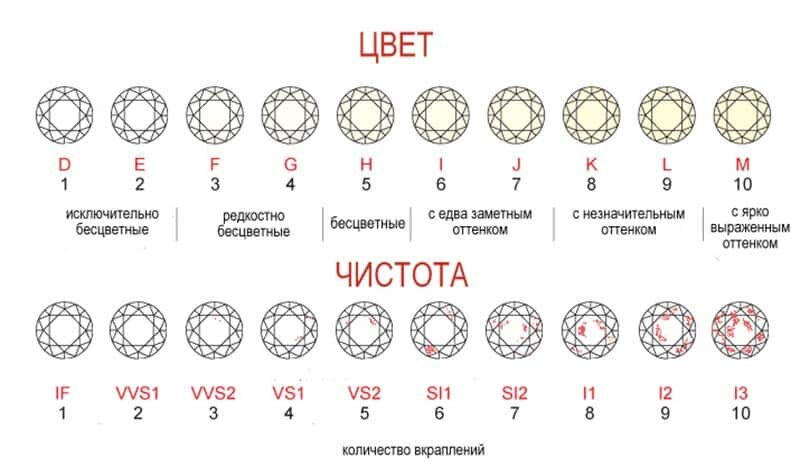

In [10]:
# огранка имеет иерархию
cut_mapping = {'Ideal': 0,
               'Premium': 1,
               'Very Good': 2,
               'Good': 3,
               'Fair': 4}

data['cut'] = data['cut'].map(cut_mapping).astype('int8')
data['cut'].value_counts()

cut
0    21488
1    13748
2    12069
3     4891
4     1598
Name: count, dtype: int64

In [11]:
# цвет имеет иерархию
color_mapping = {'D': 0,
                 'E': 1,
                 'F': 2,
                 'G': 3,
                 'H': 4,
                 'I': 5,
                 'J': 6}

data['color'] = data['color'].map(color_mapping).astype('int8')
data['color'].value_counts()

color
3    11262
1     9776
2     9520
4     8272
0     6755
5     5407
6     2802
Name: count, dtype: int64

In [12]:
# чистота имеет иерархрию
clarity_mapping = {'I1': 7,    
                   'SI2': 6,  
                   'SI1': 5, 
                   'VS2': 4,
                   'VS1': 3, 
                   'VVS2': 2,
                   'VVS1': 1,         
                   'IF': 0}

data['clarity'] = data['clarity'].map(clarity_mapping).astype('int8')
data['clarity'].value_counts()

clarity
5    13032
4    12229
6     9150
3     8156
2     5056
1     3647
0     1784
7      740
Name: count, dtype: int64

# 5. Проверка данных

In [13]:
data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53794 non-null  float64
 1   cut      53794 non-null  int8   
 2   color    53794 non-null  int8   
 3   clarity  53794 non-null  int8   
 4   depth    53794 non-null  float64
 5   table    53794 non-null  float64
 6   price    53794 non-null  int64  
 7   x        53794 non-null  float64
 8   y        53794 non-null  float64
 9   z        53794 non-null  float64
dtypes: float64(6), int64(1), int8(3)
memory usage: 3.4 MB


In [14]:
data.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,0,1,6,61.5,55.0,326,3.95,3.98,2.43
1,0.21,1,1,5,59.8,61.0,326,3.89,3.84,2.31
2,0.23,3,1,3,56.9,65.0,327,4.05,4.07,2.31
3,0.29,1,5,4,62.4,58.0,334,4.20,4.23,2.63
4,0.31,3,6,6,63.3,58.0,335,4.34,4.35,2.75
5,0.24,2,6,2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,2,5,1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,2,4,5,61.9,55.0,337,4.07,4.11,2.53
8,0.22,4,1,4,65.1,61.0,337,3.87,3.78,2.49
9,0.23,2,4,3,59.4,61.0,338,4.00,4.05,2.39


Данные выглядят **чистыми** и **информативными**

# 6. Исследование основных параметров

**Основные параметры:**
- Карат
- Огранка
- Цвет
- Чистота
- Глубина
- Табличная ширина
- Цена
- Объём

In [15]:
data.describe()

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,1.095866,2.593914,3.948080,61.748080,57.458109,3933.065082,5.731956,5.735290,3.539960
std,0.47339,1.116098,1.701117,1.646857,1.429909,2.233679,3988.114460,1.118786,1.139601,0.701893
min,0.20000,0.000000,0.000000,0.000000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.40000,0.000000,1.000000,3.000000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,1.000000,3.000000,4.000000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,2.000000,4.000000,5.000000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,4.000000,6.000000,7.000000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


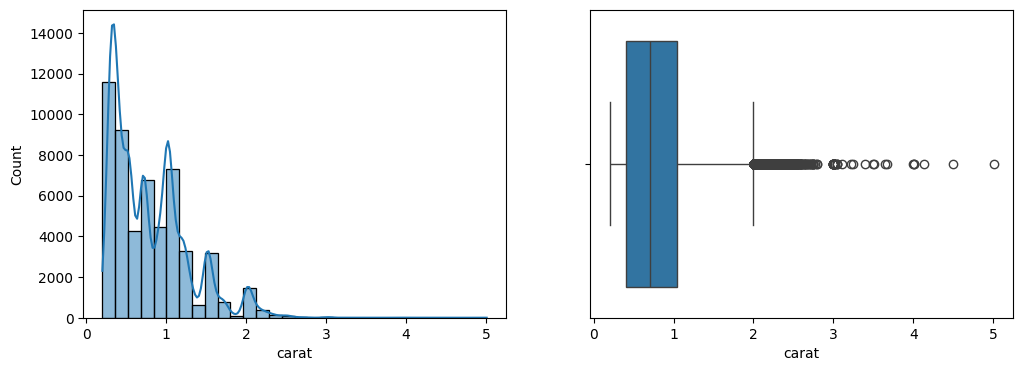

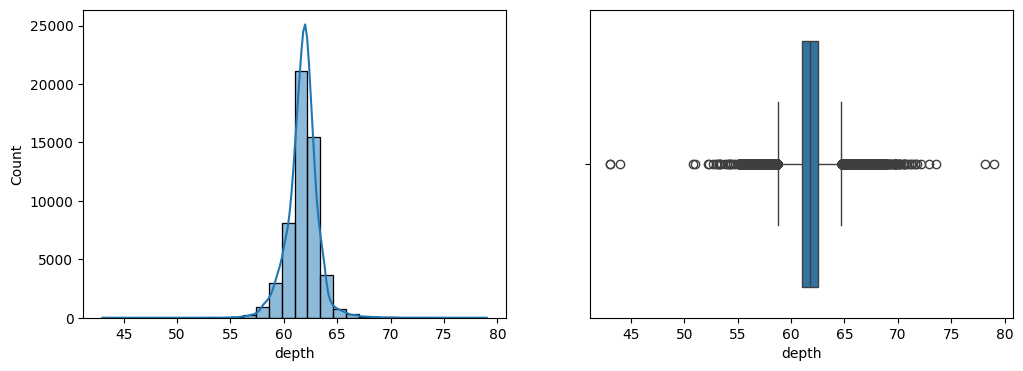

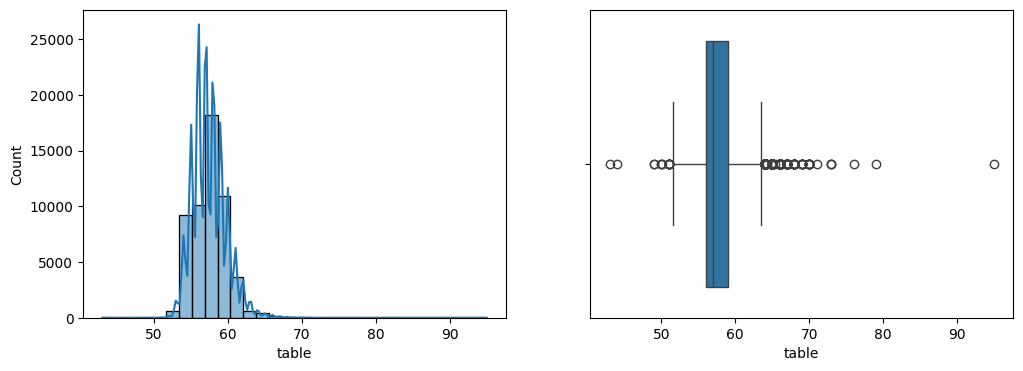

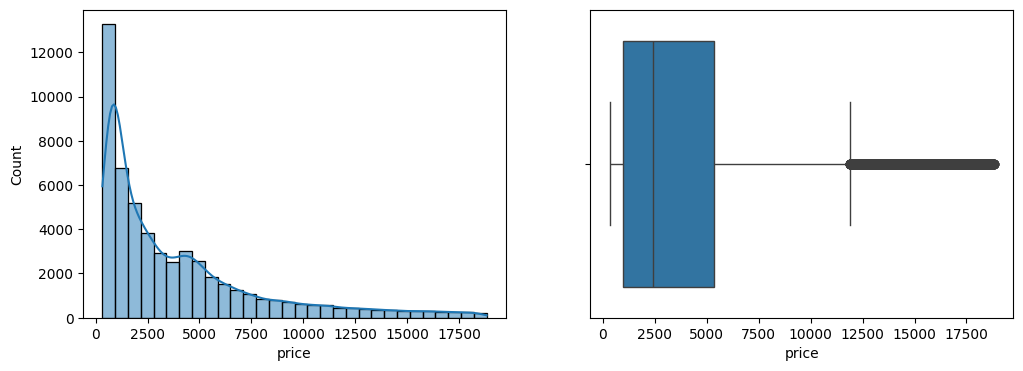

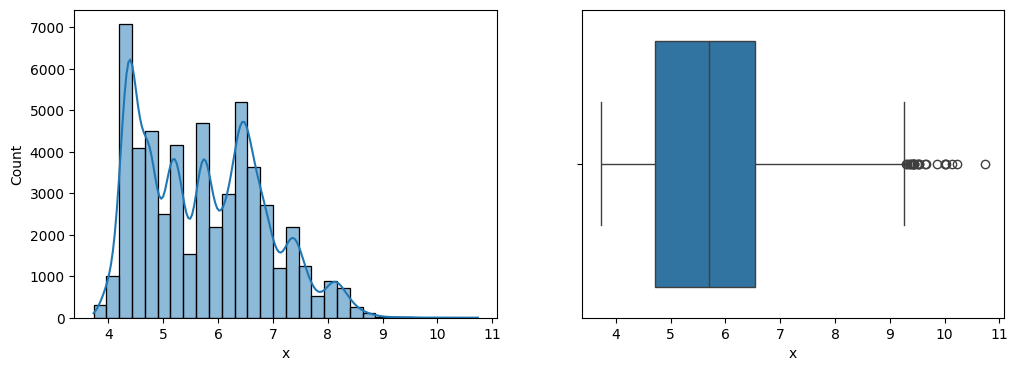

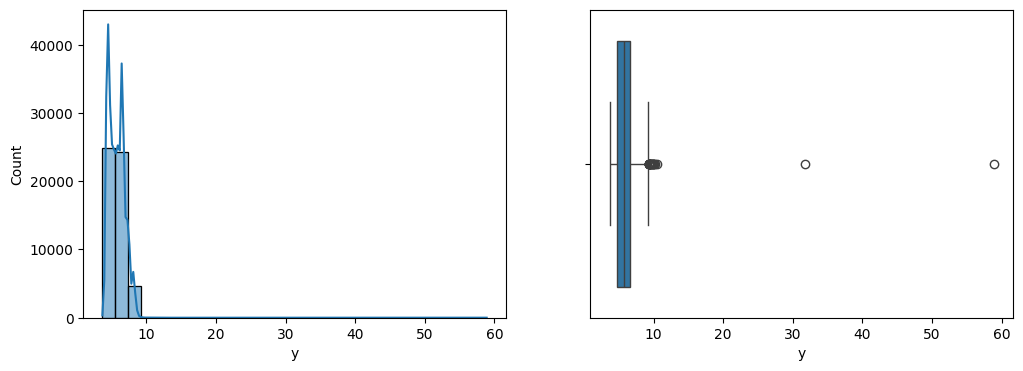

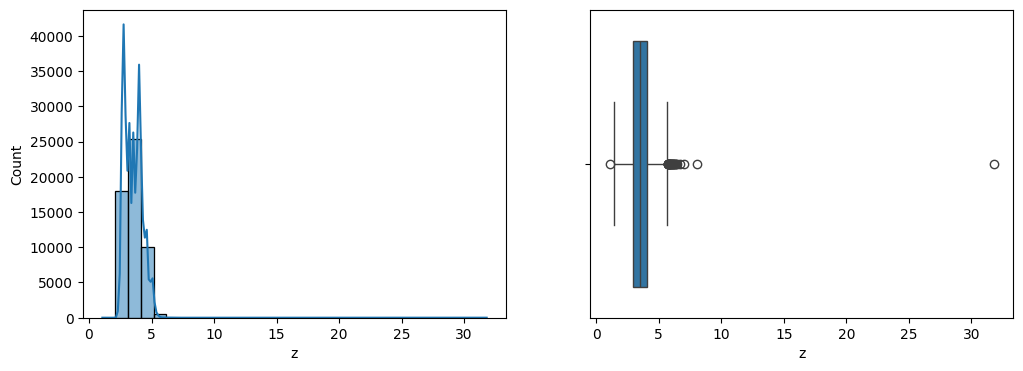

In [16]:
columns = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

for col in columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data[col], bins=30, kde=True, ax=axes[0])
    sns.boxplot(x=data[col], ax=axes[1])
    plt.show()

Поля карат, глубины, табличной ширины и объёма имеют выбросы, затрудняющие чтение данных

# 7. Изучение и обработка выбросов

In [17]:
outlier = data[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']]
Q1 = outlier.quantile(0.25)
Q3 = outlier.quantile(0.75)
IQR = Q3-Q1
data_filtered = outlier[~((outlier < (Q1 - 1.5 * IQR)) | (outlier > (Q3 + 1.5 * IQR))).any(axis=1)]

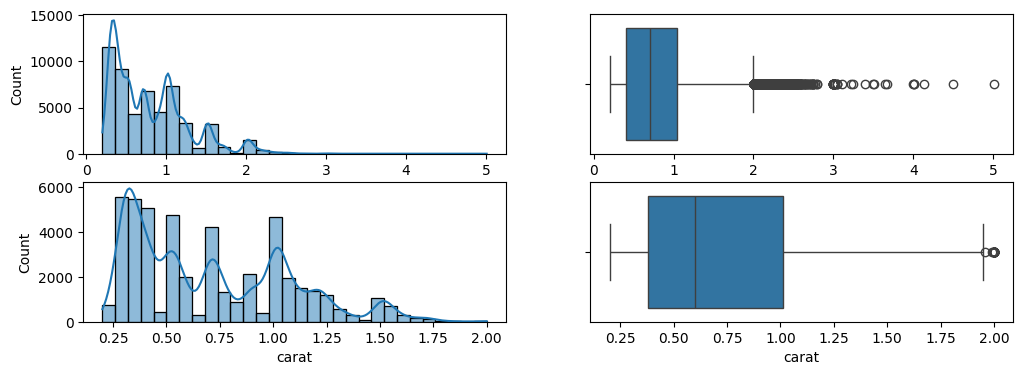

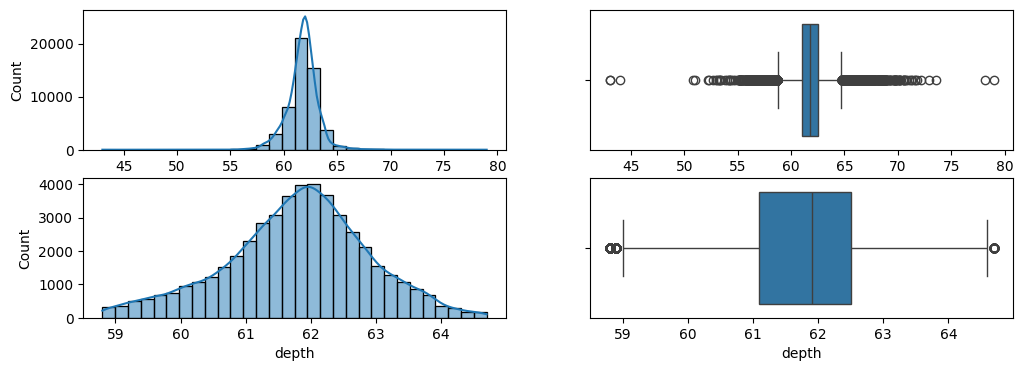

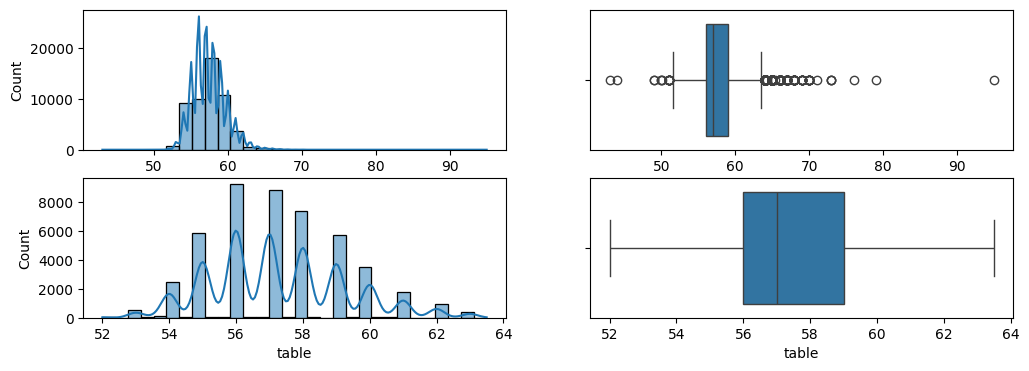

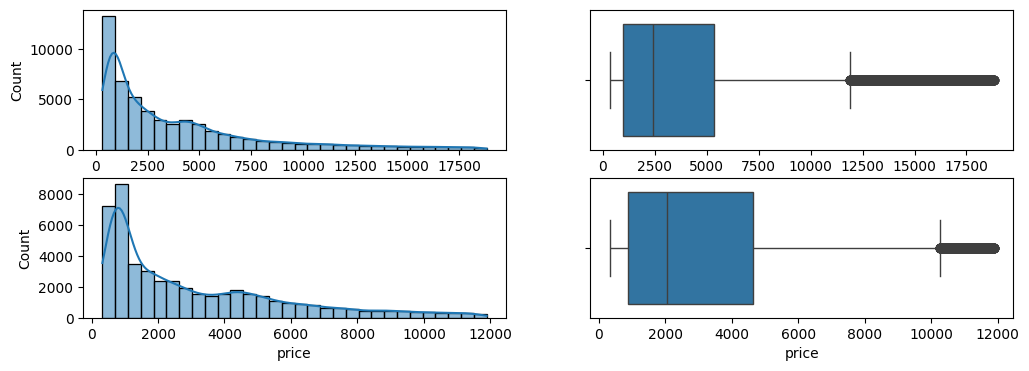

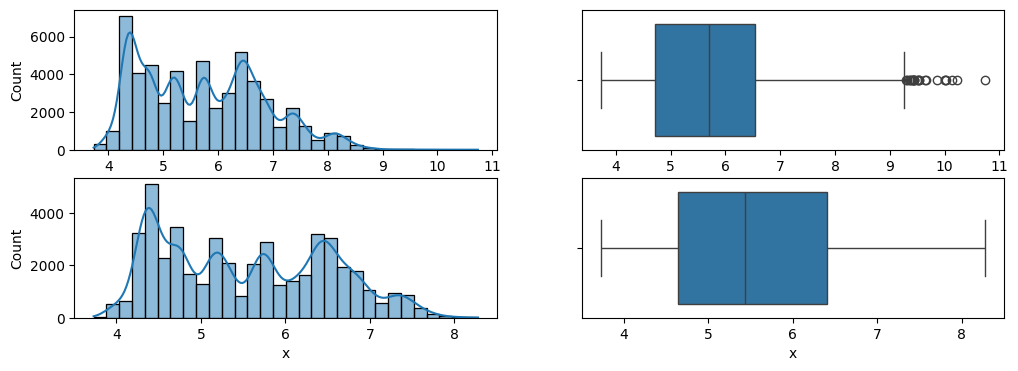

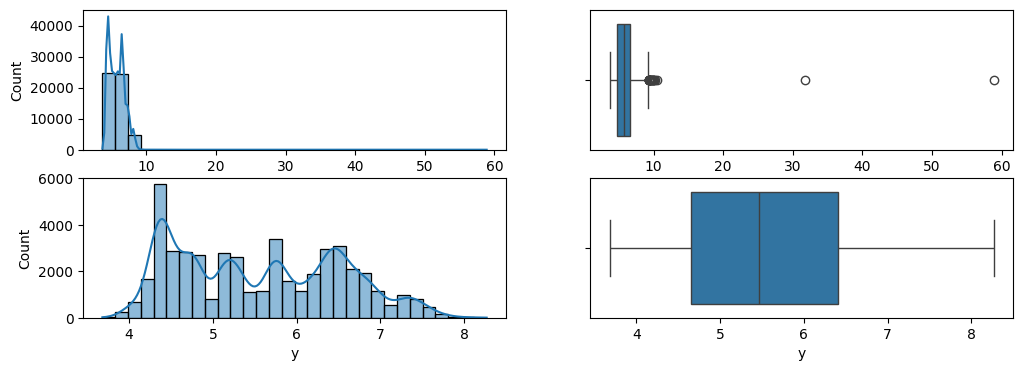

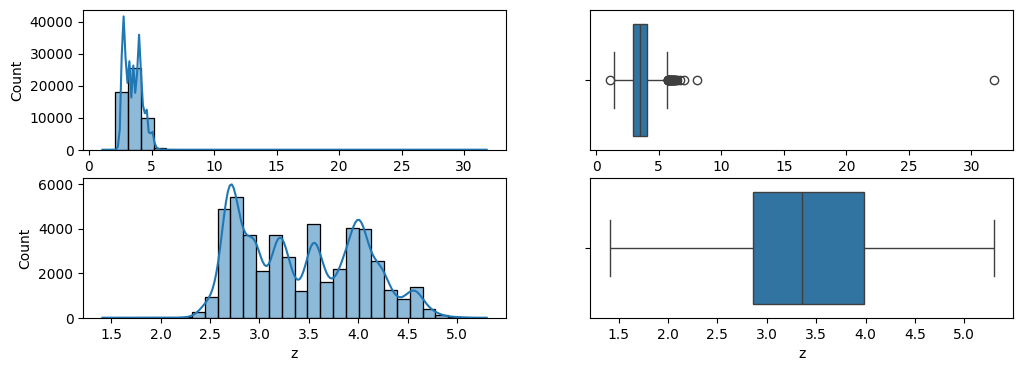

In [18]:
for col in data_filtered.columns:
    fig, axes = plt.subplots(2, 2, figsize=(12, 4))
    # данные до обработки выбросов
    sns.histplot(data[col], bins=30, kde=True, ax=axes[0, 0])
    sns.boxplot(x=data[col], ax=axes[0, 1])
    # данные после обработки выбросов
    sns.histplot(data_filtered[col], bins=30, kde=True, ax=axes[1, 0])
    sns.boxplot(x=data_filtered[col], ax=axes[1, 1])
    plt.show()

**Заключение:**
- У карат есть три пика, у которых сосредоточено основное количество данных
- Чаще алмазы находят рядом на глубине около 62
- Наиболее распространённые табличные значения ширины - 56, 57
- Очень часто встречаются алмазы с объёмом 50

# 8. Исследование основных параметров без выбросов

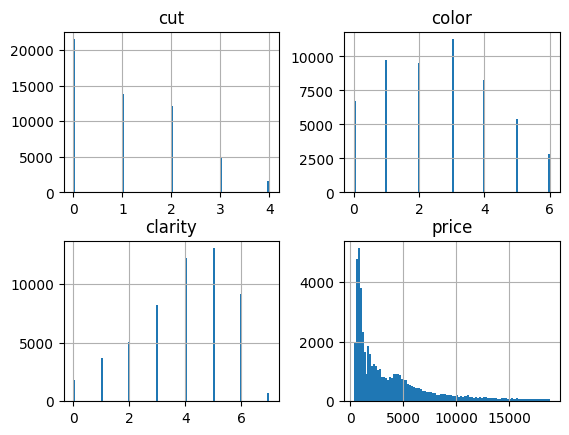

In [19]:
columns = [['cut', 'color', 'clarity', 'price']]

for column in columns:
    data.hist(column, bins=100)

**Заключение:**
- Чаще всего встречается лучшая огранка
- Цвет алмаза сфокусирован в центре значений, из этого следует, что алмазы скорее будут иметь оттенок, чем будут чистыми
- Большее количество алмазов имеют заметные вкрапления
- Цены алмазов в основном составляют ~1000

# Анализ влияния параметров на цену

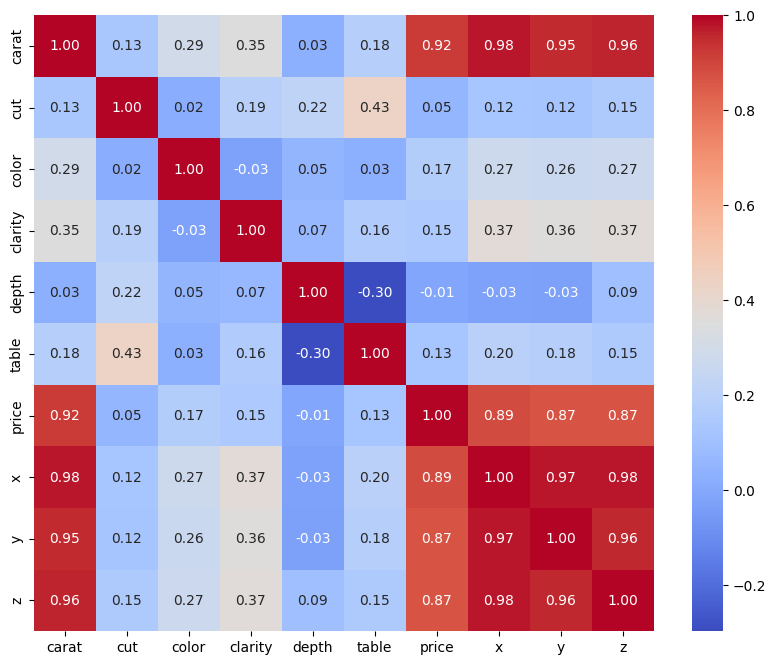

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

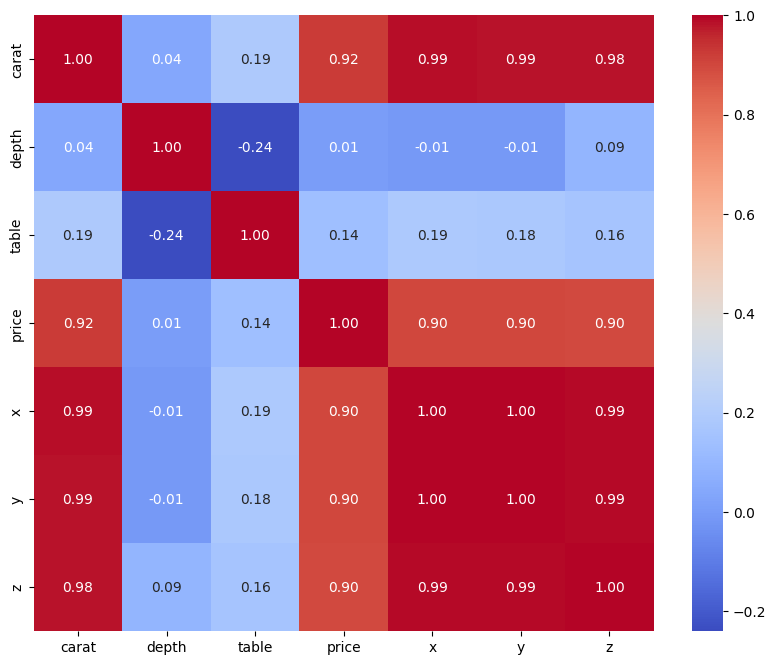

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(data_filtered.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

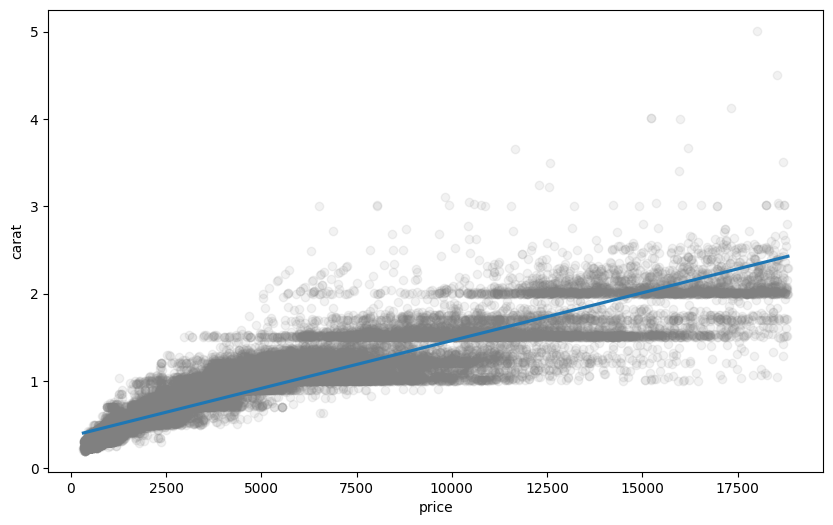

In [22]:
plt.figure(figsize=(10, 6))
sns.regplot(data=data, x='price', y='carat', scatter_kws={'alpha':0.1, 'color':'gray'})
plt.show()

In [23]:
data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53794 non-null  float64
 1   cut      53794 non-null  int8   
 2   color    53794 non-null  int8   
 3   clarity  53794 non-null  int8   
 4   depth    53794 non-null  float64
 5   table    53794 non-null  float64
 6   price    53794 non-null  int64  
 7   x        53794 non-null  float64
 8   y        53794 non-null  float64
 9   z        53794 non-null  float64
dtypes: float64(6), int64(1), int8(3)
memory usage: 3.4 MB


In [24]:
data_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47425 entries, 0 to 53939
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   carat   47425 non-null  float64
 1   depth   47425 non-null  float64
 2   table   47425 non-null  float64
 3   price   47425 non-null  int64  
 4   x       47425 non-null  float64
 5   y       47425 non-null  float64
 6   z       47425 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.9 MB


# Вывод

**Ход работы:**
1. Знакомство с данными
2. Работа с пропущенными данными
3. Коррекция типов
4. Обогащение данных
5. Проверка данных
6. Исследование основных параметров
7. Исследование и обработка выбросов
8. Исследование данных без выбросов
9. Анализ влияния параметров на цену

**Полученные результаты:**
- Цена явно зависит от объёма
- Количество карат, пусть и очевидно, но тоже зависит от объёма

In [26]:
data.update(data_filtered)
data.to_csv(r'D:\Python\OmSTU\NLP\lab_1\data\post_diamonds.csv', index=False)
